# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Karla Palos Castellanos

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
# Import libraries

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split

In [2]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

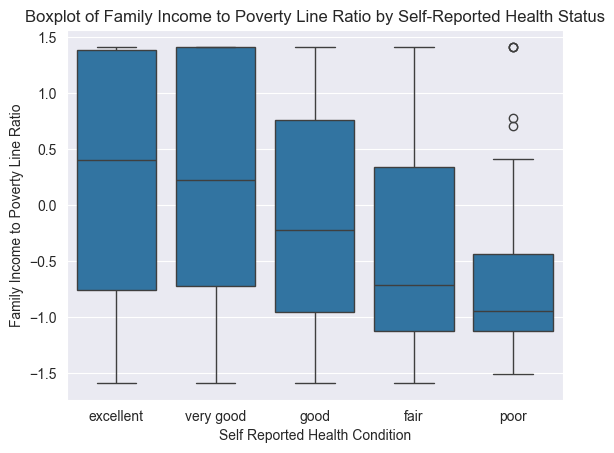

In [3]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

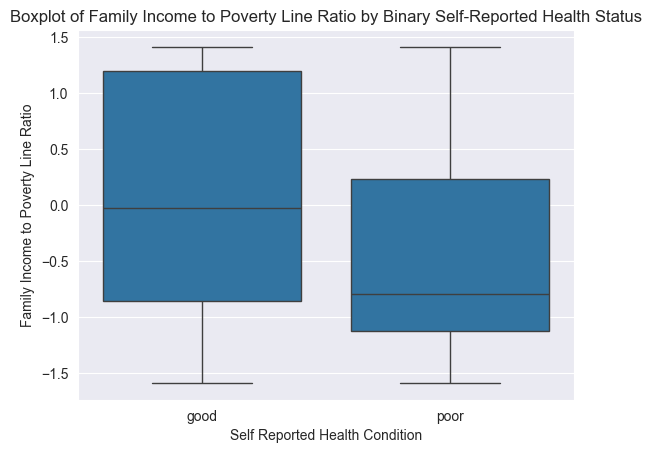

In [4]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

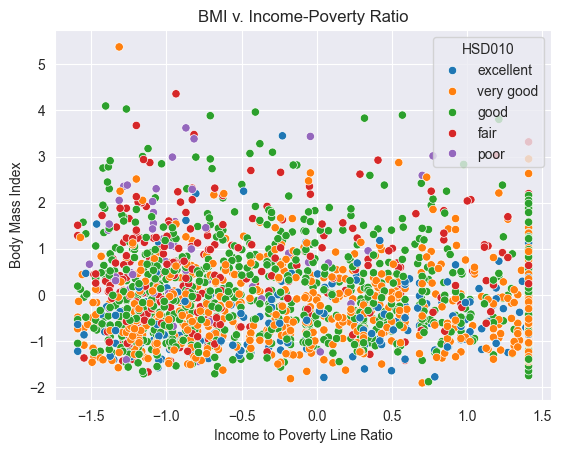

In [5]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [6]:
# renamed nhanes_scales so that we can create an array of features
nhanes_scaled_X = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)


## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

### Train PCA and Discuss Number of Components

In [7]:
# inspect the features 
nhanes_scaled_X.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ033,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,-0.680203,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,-0.680203,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-0.680203,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812


In [8]:
# create array of target data
hsd010_labels =  nhanes_scaled[['HSD010', 'HSD010_binary']]
hsd010_labels.head()


,HSD010,HSD010_binary
SEQN,,
73568,excellent,good
73576,excellent,good
73579,very good,good
73581,very good,good
73584,good,good


In [9]:
#Let's take a look at the "label" column that will be our target:

# view label column
nhanes_scaled['HSD010'].unique()

array(['excellent', 'very good', 'good', 'fair', 'poor'], dtype=object)

In [10]:
# load library 
# ----------
from sklearn.decomposition import PCA

# apply PCA
# ----------
pca = PCA(20)
PCA_nhanes = pca.fit_transform(nhanes_scaled_X)

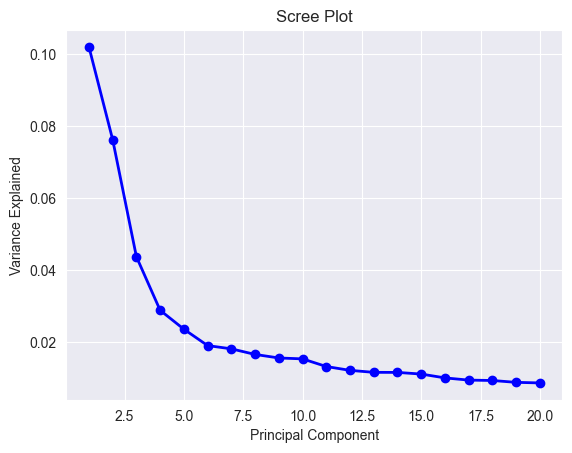

In [11]:
# create scree plot from PCA fit
# ----------
PCA_values = np.arange(pca.n_components_) + 1

plt.plot(PCA_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

### Observations

- There is a steep drop in explained variance for the first few components.
- There is an elbow (where the slope changes from steep to flatter) roughly around components 4–6.
- There is a flatter tail after roughly 8–10 components --> note: each additional component adds only a small amount of variance.

Interpretation
- Early components --> capture broad and more systemic variation.
- Later components --> capture more specific patterns, but each adds less variation than earlier components.
- After the elbow --> diminishing returns in the variation explained.

Notes:
- I used different values in the PCA. First, I tried 10, then 20, 30, etc., and I noticed that there is not a big difference in the additional variance explained by each component after about 15. Everything looks roughly flat with a slow decrease after ~15, so we are going to choose 20 for now. 

- This plot does not tell us how much variance is good enough or what the exact number to use for prediction is. It just shows that variance decreases gradually and that using too few components might miss meaningful structure in the variation.

### Barplot of Components

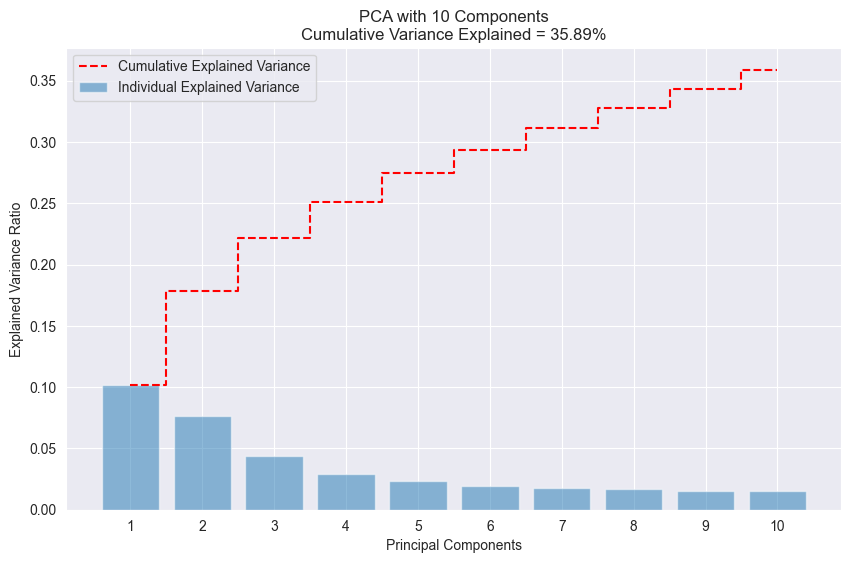

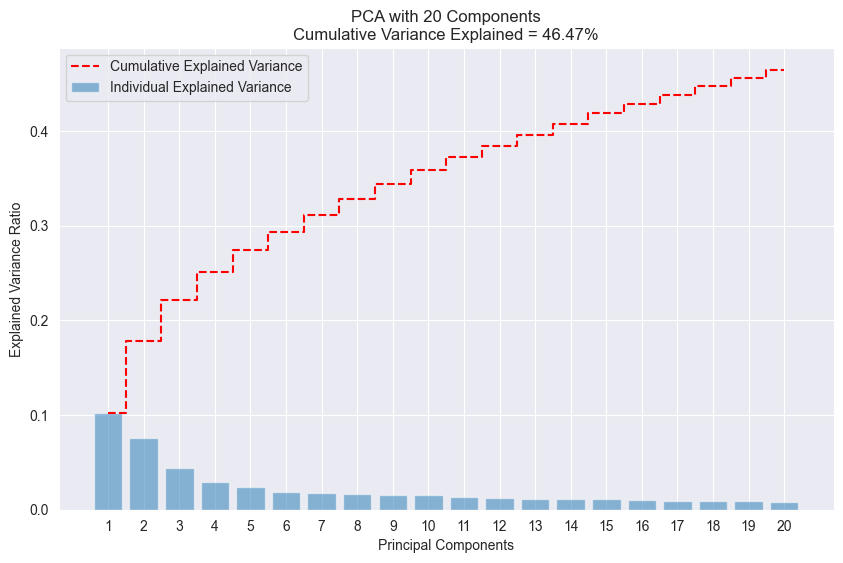

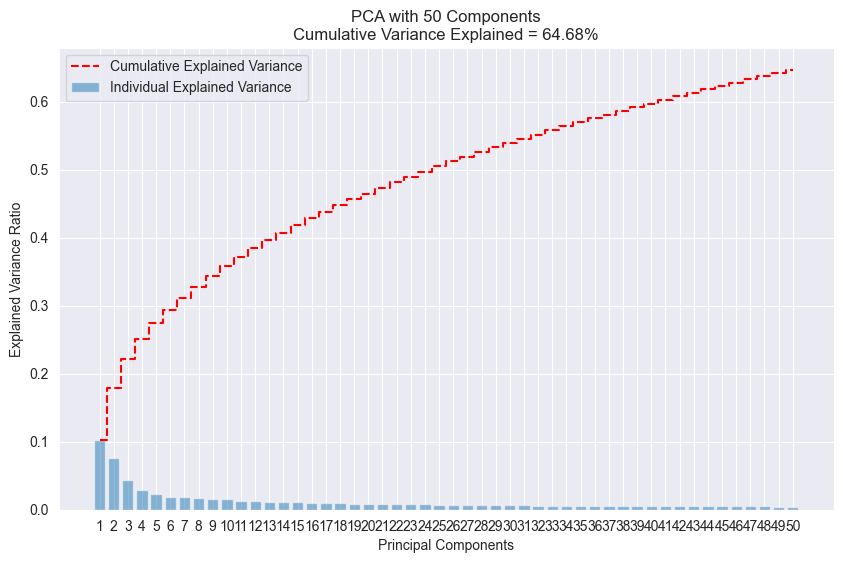

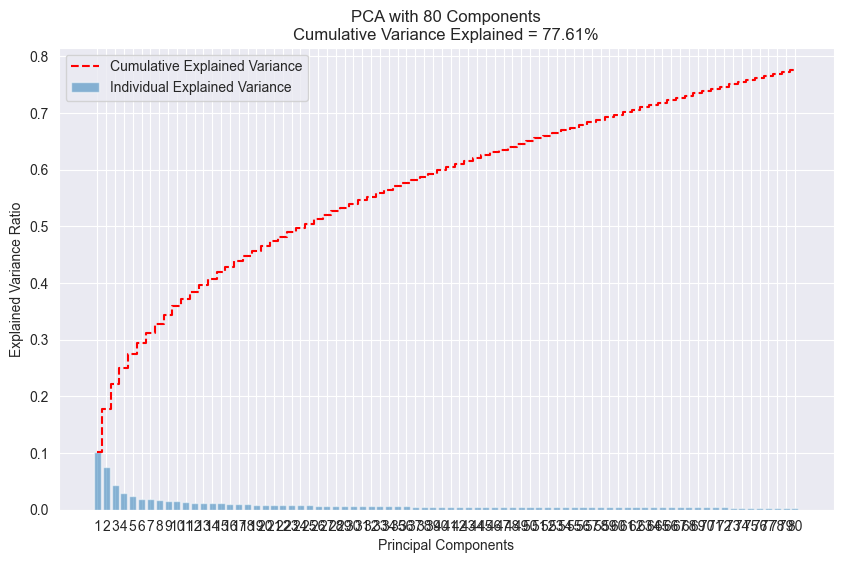

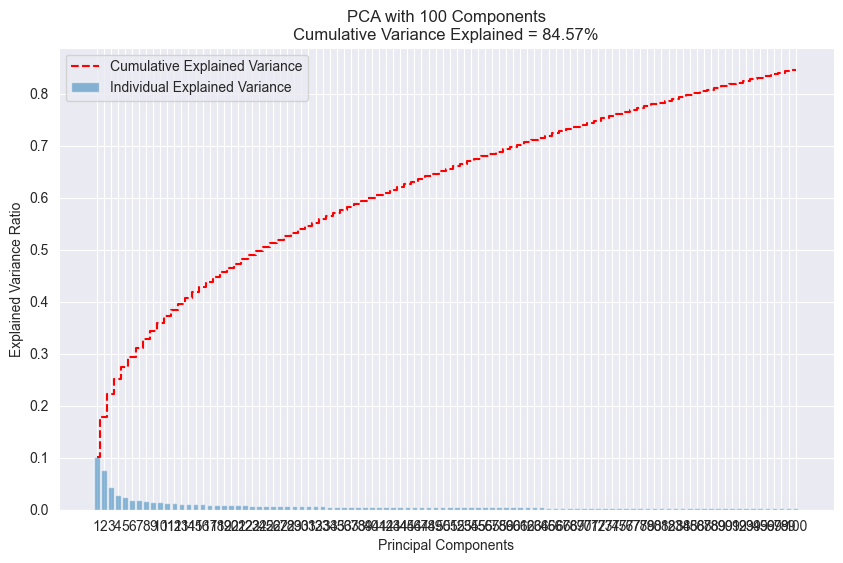

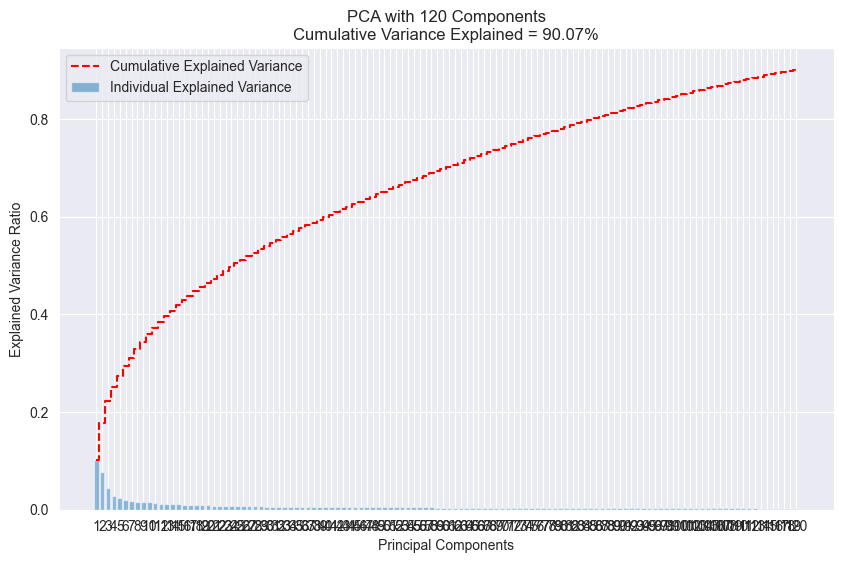

In [12]:
# fit PCA

# Define how many PCA values we want to try 
pca_values = [10,20,50,80,100,120]

for n_components in pca_values:

        # fit PCA
    pca_ = PCA(n_components=n_components) # notice that we tried a few values here (10,15,20...) 
    principalComponents_nhanes = pca_.fit_transform(nhanes_scaled_X)
    
    # explained variance
    explained_variance_ratio = pca_.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    total_variance = cumulative_variance[-1]

    # plot 
    plt.figure(figsize=(10, 6))
    
    # Plot individual explained variance 
    # ----------
    plt.bar(range(1, len(explained_variance_ratio) + 1),
            explained_variance_ratio,
            alpha=0.5, 
            align='center', 
            label='Individual Explained Variance')
    
    # Plot cumulative explained variance 
    # ----------
    plt.step(range(1, len(cumulative_variance) + 1), 
             cumulative_variance, 
             where='mid', 
             color='red', 
             linestyle='--',
             label='Cumulative Explained Variance')
    
    plt.ylabel('Explained Variance Ratio')
    plt.xlabel('Principal Components')  
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.title(
        f'PCA with {n_components} Components\n'
        f'Cumulative Variance Explained = {total_variance:.2%}'
    ) 
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

### Observatios

- For this plot we once again tried a range of principal components. After about 10, the amount of variance explained by each extra component becomes small and fairly similar across additional components, rather than dropping to near zero.

- The blue bars indicate the invidual explained variance. The first bar, which represents PC1, explains about 10% of the variation, PC2, adds only about 7-8% of the explained variance, PC3 adds about 4-5%, and after about PC5, each bar only adds a relatively small amount.

- In other words, a large share of the variation is captured in the first few components, but not the majority. The variance continues to accumulate across many additional components.

- The red line shows the cumulative variation explaioned, this is th total variance as we add ned components. So above. we can see that the 3 components expalines about 23% of the variation, the first 10 explain about 35%, and the frist 20, just under 50%. (This behvaior is typical for datasets with a lot of variables). Note, that once again, this does not tell us that we captures the majority of the variance or that 20 components are optimal, it just tell us that the there is a gradual reduction in dimensionality, and that if we use too few components we might miss a meaningul structure in the variation.

### How many components will you use to fit a supervised learning model?

The cumulative explained variance curve didn't show a clear "elbow".  Instead, it gradually increased even after adding 15–20 components. This shows that the variance is spread out over many components instead of being concentrated in just a few important ones. One approach could be to pick a point where the additional gains are very small (around 20 components) but that would keep less than half of the total variance, just at 47%. 

Since the increase in explained variance is gradual, just using the elbow method isn't enough to decide on the number of components. So, I chose a goal-based rule: I kept the number of components that capture about 80% of the total variance. Following this guideline, I decided to keep 100 principal components for the supervised learning model. This choice balances reducing dimensions and not losing information. Finally, it is imporantant to note that some components might just be noise rather than useful signals.

### 2D Scatterplot of the first two components

<Figure size 640x480 with 0 Axes>

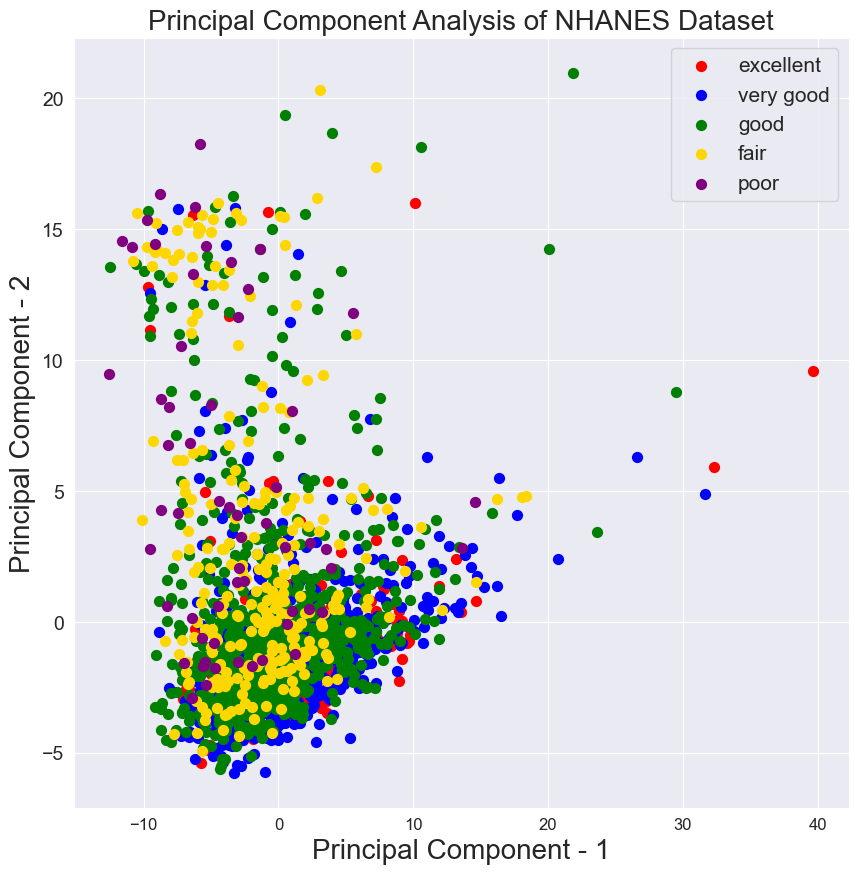

In [13]:
# convert into a dataframe
# ----------
pca_100 = PCA(n_components=100)
principalComponents_nhanes = pca_100.fit_transform(nhanes_scaled_X)
pca_two_comp = pd.DataFrame(data = principalComponents_nhanes[:, 0:2],
                      columns = ['principal component 1', 
                                 'principal component 2'])

# reset index to begin with 0 so that the mask will match up with index of the pca_two dataframe
nhanes_y = pd.DataFrame(nhanes_scaled['HSD010'])
nhanes_y = nhanes_scaled.reset_index()

# bind columns between the dataframe with the first two principal components and the health binary for scatterplot visualization
pca_df = pd.concat([pca_two_comp , nhanes_y], axis=1)

# plot
# ----------

# figure settings
plt.figure();
plt.figure(figsize=(10,10));
plt.xticks(fontsize=12);
plt.yticks(fontsize=14);
plt.xlabel('Principal Component - 1',fontsize=20);
plt.ylabel('Principal Component - 2',fontsize=20);
plt.title("Principal Component Analysis of NHANES Dataset",fontsize=20);
targets = ['excellent', 'very good', 'good', 'fair', 'poor']
colors = ['red', 'blue', 'green', 'gold', 'purple']

# loop over targets and colors to create scatterplot
for target, color in zip(targets,colors):
    indicesToKeep = nhanes_y['HSD010'] == target
    plt.scatter(pca_df.loc[indicesToKeep, 'principal component 1']
               , pca_df.loc[indicesToKeep, 'principal component 2'], c = color, s = 50);

# show figure
plt.legend(targets,prop={'size': 15})
plt.show();

### Observations

- This plot shows the first 2 PC of our data, with the color of our dots repreenting the self reported health status.
- We can see that there is a lot of overlap across all of the 5 health categories. This means that the first 2 components do not do a great job at separating people by the health status.
- In particular, eventhough PC1 captures a lot of the overall vaiation, people acorss all the categories appear in its range. This means that PC1 captures the broad population level variation instead of just a specific health status.
- PC2 seems to capture some more of the structure, but again there is no clear distinct separation by health category.
- In summary, this plot indicates that health status is driven by multiple dimensions of variation, many of which are not captured in just the first two componets. 

## Clustering

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

For this section, I use the k-means clustering algorithm because it works well with standardized data and scales efficiently to large datasets such as the one we are using.
K-means produces clusters that are straightforward to interpret and pairs well with PCA, which reduces noise and emphasizes the dominant structure in the data. 

(I also have used k-means before =) ) 

### Cluster nhanes

In [14]:
# set random seed for reproducibility 
    # --> we need this since kmeans uses random initialization
np.random.seed(1234)

# Preparing to evaluate the different number of clusters 

inertias = [] # stoe a fit quality of metric for each K 
K_range = range(1, 20)  # tests K-means solutions with increasing numbers of 
                        # clusters in order to evaluate how model fit improves
                        # and to identify the point of diminishing returns, which is our elbow.

for k in K_range:
    kmeans = KMeans(n_clusters=k, 
                    random_state=42) # fixed random seed for consistent results
    kmeans.fit(nhanes_scaled_X)      # fits the model to the scaled NHANES -
                                     # -> Each observation is assigned to the nearest centroid, 
                                     # and then Centroids are iteratively updated
    inertias.append(kmeans.inertia_)   # Record the inertia --> inertia = within-cluster sum of squared distances
                                       # Measures how compact the clusters are --> Lower inertia = tighter clusters
                                       # Inertia always decreases as k increases. 
                                       # in other words, we want to store how well the data fit when I use k clusters. 


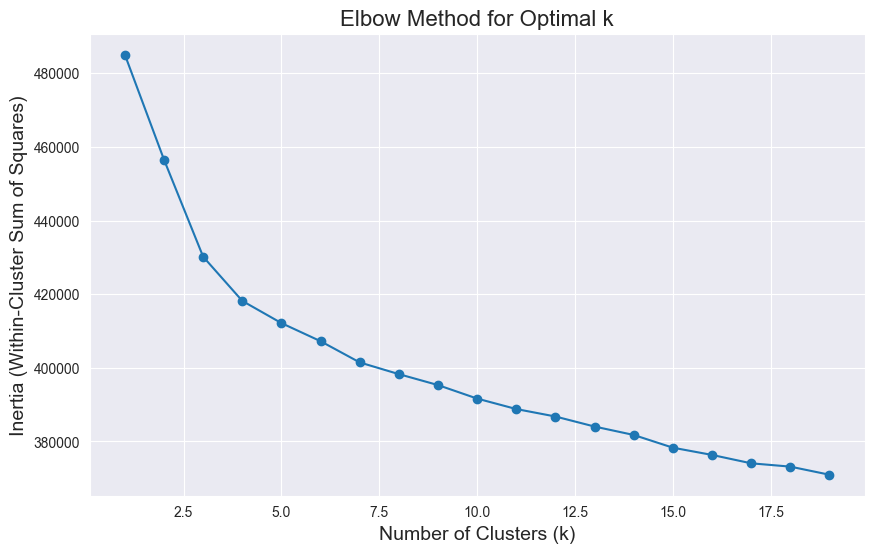

In [15]:
# plot
# ----------

plt.figure(figsize=(10,6))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=14)
plt.title('Elbow Method for Optimal k', fontsize=16)
plt.grid(True)
plt.show()

### Observations
- Sharp drop in inertia from k = 1  to K=3
- The rate of improvement slows after k ≈ 4/5
- After K=4/5, the inertia continues to decline, but it appears to do so linearly and only with small marginal gains
- In summary, the "elbow" appears roiughly at K =4 or 5

In [16]:
# specify kmeans algorithm -->  commiting to 5 clusters 
# ----------
kmeans = KMeans(n_clusters=5,
                random_state = 42, # fixing random centroid initialization
                n_init=10,# This is done to run the K-means 10 separate time with diffrent rendom initial centroids. 
                            # our solution will be the one with the lowest inertia
                max_iter=1000000 #max number of iter per run/ K means will stop earlier if it converges.
                ).fit(nhanes_scaled_X) # fits the model to the scaled data 


### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

In [17]:
# create numpy array of coordinates needed for scatterplot
plot_data = nhanes_scaled_X[['INDFMPIR', 'BMXBMI']].to_numpy()

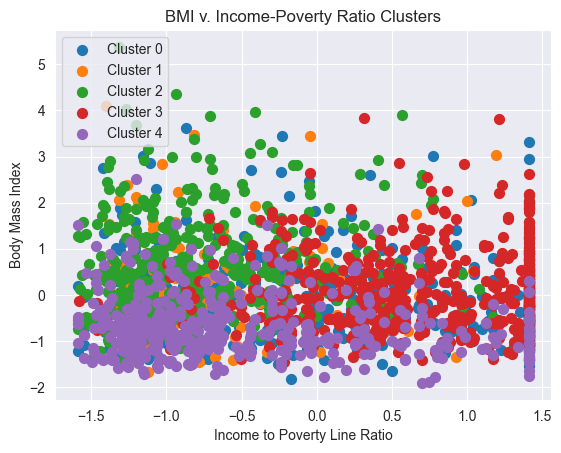

In [18]:
# figure settings
fig, ax = plt.subplots()


# plot
for lab in range(kmeans.n_clusters):
    ax.scatter(
        *plot_data[kmeans.labels_ == lab, :].T,
        s=50,
        label=f"Cluster {lab}"
    )

plt.legend(loc='upper left')
plt.xlabel("Income to Poverty Line Ratio")
plt.ylabel("Body Mass Index")
plt.title("BMI v. Income-Poverty Ratio Clusters")
plt.show()

### Observations
- Colors indicate each of the clusters from the 5-cluster in the kmeans
- each point in an individual plotted in the income-poverty by BMI
- There is a lager overlap in the plot
- There seems to be a larger separation of the points along the income dimensions than the BMI one
- The overlap is expected because in the k-means we fitted ysing mulple variables, and the way that the clusters are separated may occur along different dimenstions that cannot be shown in this plot. 

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

In [19]:
# specify kmeans algorithm
# ----------
kmeans = KMeans(n_clusters=5, 
                random_state = 42,
                n_init=10,
                max_iter=1000000, 
                ).fit(principalComponents_nhanes)

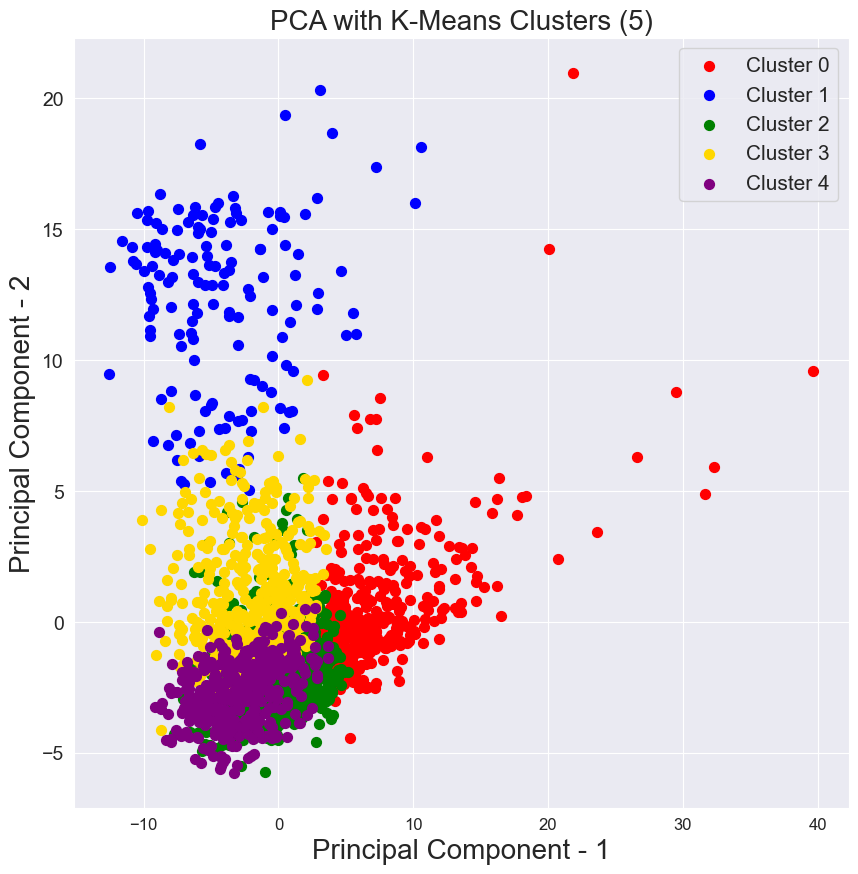

In [20]:
# plot
# ----------

# figure settings
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize=20)

plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("PCA with K-Means Clusters (5)", fontsize=20)

colors = ['red', 'blue', 'green', 'gold', 'purple']

labels = kmeans.labels_

for cluster_id, color in enumerate(colors):
    mask = labels == cluster_id
    plt.scatter(
        pca_df.loc[mask, 'principal component 1'],
        pca_df.loc[mask, 'principal component 2'],
        c=color,
        s=50,
        label=f"Cluster {cluster_id}"
    )

plt.legend(prop={'size': 15})
plt.show()

### Observations
- The clusters seem more clearly separated in this PCA plot than in the BMI-income plot.
- There is still some overlap between the clusters, which again is expected since this is part of the nature of the unsupervised algorithm
- The separation is most noticible along the PC1, and we can see this through how the clusters are occupying visible different regions along the PC1 axis
- Using the PC before the clusturing helpes us see some infromation about the data that was not easy ti splot when we simply plotted the two variables alone. This is an indication that the way the clusters are organized is through different variables instead of any single variable (as we saw the case with BMI or inciome)
- Caution: It is importnat to now that since we are only plotting the first 2 components, some of the distinctions among the clusters are likely not visiable here. 


## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [21]:
# partition data
# -----------
y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0]) # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already 
X = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)# drop out any columns that aren't features

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

/var/folders/m5/b_w_2h3x7k51vm4jpn8pct7c0000gn/T/ipykernel_28984/2198733933.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0]) # either hsd010 or hsd010_binary, may need to convert to numeric if it isn't already


In [22]:
# load libraries
# -----------
import keras
from keras.utils import to_categorical


keras.utils.set_random_seed(42)

num_classes = 2
# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

In [23]:
# convert training data to numpy arrays
x_train = X_train.to_numpy()
x_test = X_test.to_numpy()

# Convert the data type from int to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# get dimensions of data
n_features = X_train.shape[1]

In [24]:
# create neural network model
# -----------
model = Sequential()

# input
model.add(Dense(n_features,           # number of neurons
          input_dim=n_features,       # input shape
          kernel_initializer='normal',  # method for initializing weights 
          activation='relu')            # Relu: its a good standard baseline activation for neworks where the information flows one way (such is the case here)
)

# output
model.add(
    Dense(num_classes,                 # number of output units,
          kernel_initializer='normal',
          activation='softmax')        # softmax turns output to probabilities (sums to 1).Also good for multi-classification
)

## Add any additional layers you wish here

model.compile(loss='categorical_crossentropy',   # specify the loss function
              optimizer='adam',                  # Adam is an optimizer that: 
                                                 # - atomatically adapts the learning rate druing the training 
                                                 # - Works well with minimal tuning 
                                                 # Chose this becase 1) the dataset is moderate sixze, 2)  not hyperparametrizing a lot 
              metrics=['accuracy'])             


model.fit(x_train,                  
          y_train,                  
          validation_data=(x_test,  
                           y_test), 
          epochs=10,                # number of iterations back and forth through the network
          batch_size=500,           # number of rows it will input per batch 
          verbose=2);               # print as it goes

# Summary: 
# - The model is getting the input (standarized) --> relu hidden layer --> somax output
#  - The neural network is trained on standardized input features, which is important for stable optimization and effective learning in neural networks.
# - uses categorical cross-entropy 
# - trains with Adam 


Epoch 1/10


/Users/karla/venvs/soc271/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 - 1s - 222ms/step - accuracy: 0.4858 - loss: 0.7368 - val_accuracy: 0.7771 - val_loss: 0.5342
Epoch 2/10
4/4 - 0s - 11ms/step - accuracy: 0.8295 - loss: 0.4484 - val_accuracy: 0.8353 - val_loss: 0.4071
Epoch 3/10
4/4 - 0s - 12ms/step - accuracy: 0.8650 - loss: 0.3516 - val_accuracy: 0.8430 - val_loss: 0.3705
Epoch 4/10
4/4 - 0s - 11ms/step - accuracy: 0.8727 - loss: 0.3214 - val_accuracy: 0.8527 - val_loss: 0.3637
Epoch 5/10
4/4 - 0s - 11ms/step - accuracy: 0.8779 - loss: 0.3062 - val_accuracy: 0.8547 - val_loss: 0.3617
Epoch 6/10
4/4 - 0s - 11ms/step - accuracy: 0.8857 - loss: 0.2909 - val_accuracy: 0.8585 - val_loss: 0.3615
Epoch 7/10
4/4 - 0s - 11ms/step - accuracy: 0.8921 - loss: 0.2770 - val_accuracy: 0.8547 - val_loss: 0.3612
Epoch 8/10
4/4 - 0s - 11ms/step - accuracy: 0.8966 - loss: 0.2639 - val_accuracy: 0.8547 - val_loss: 0.3587
Epoch 9/10
4/4 - 0s - 11ms/step - accuracy: 0.9018 - loss: 0.2502 - val_accuracy: 0.8547 - val_loss: 0.3549
Epoch 10/10
4/4 - 0s - 11ms/step - acc

### Neural Network on Principal Components

In [25]:
y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0])  

X_train_pca, X_test_pca, y_train, y_test = train_test_split(principalComponents_nhanes, 
                                                    y, 
                                                    test_size = .25,   
                                                    random_state = 10)

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_features = X_train_pca.shape[1]
num_classes = y_test.shape[1]

# basically doing the same neural-net workflow we already have, we are 
# just swaping x_train / x_test (original features) for x_train_pca / x_test_pca ... 


/var/folders/m5/b_w_2h3x7k51vm4jpn8pct7c0000gn/T/ipykernel_28984/2047180553.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0])


### Neural Network on Principal Components + Cluster Membership

In [26]:
# Steps: 
# - 1. get the PCA score matric
# - 2. get the cluster labesl from kmeans,
# - 3. append them
# - 4. train the same neural network on this new aumented matrix 


In [27]:
# 1) PCA 
print(principalComponents_nhanes.shape)
# 2) kmeans 
print(kmeans.labels_.shape)
# 3) append 
principalComponents_withLabels_nhanes = np.concatenate((principalComponents_nhanes, kmeans.labels_.reshape(-1, 1)), axis=1)
print(principalComponents_withLabels_nhanes.shape)

(2064, 100)
(2064,)
(2064, 101)


In [28]:
#4) train the neureal netwrok on new matrix 


# Split data 
y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0])  

X_train, X_test, y_train, y_test = train_test_split(principalComponents_withLabels_nhanes, 
                                                    y, 
                                                    test_size = .25, 
                                                    random_state = 10)

# Data prep 

# Convert to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
num_classes = y_test.shape[1]

# Convert the data to float
x_train = X_train.astype('float32')
x_test = X_test.astype('float32')

# Get dimensions of data
num_features = X_train.shape[1]

/var/folders/m5/b_w_2h3x7k51vm4jpn8pct7c0000gn/T/ipykernel_28984/585200650.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = nhanes_scaled['HSD010_binary'].replace(['good', 'poor'], [1, 0])


In [29]:
# Fit the neural netwoks (same as before, but with new data...) 

model = Sequential()

# input 
model.add(Dense(num_features,           
          input_dim=num_features,      
          kernel_initializer='normal',  
          activation='relu'))            

# output 
model.add(
    Dense(num_classes,                
          kernel_initializer='normal', 
          activation='softmax')        
)

model.compile(loss='categorical_crossentropy',   
              optimizer='adam',                  
              metrics=['accuracy'])             

model.fit(x_train,                 
          y_train,                  
          validation_data=(x_test,  
                           y_test), 
          epochs=12,                
          batch_size=500,           
          verbose=2);               

Epoch 1/12
4/4 - 1s - 241ms/step - accuracy: 0.7778 - loss: 0.6061 - val_accuracy: 0.8430 - val_loss: 0.5307
Epoch 2/12
4/4 - 0s - 10ms/step - accuracy: 0.8353 - loss: 0.5220 - val_accuracy: 0.8488 - val_loss: 0.4723
Epoch 3/12
4/4 - 0s - 10ms/step - accuracy: 0.8379 - loss: 0.4641 - val_accuracy: 0.8488 - val_loss: 0.4325
Epoch 4/12
4/4 - 0s - 10ms/step - accuracy: 0.8379 - loss: 0.4226 - val_accuracy: 0.8469 - val_loss: 0.4058
Epoch 5/12
4/4 - 0s - 10ms/step - accuracy: 0.8417 - loss: 0.3918 - val_accuracy: 0.8469 - val_loss: 0.3876
Epoch 6/12
4/4 - 0s - 10ms/step - accuracy: 0.8463 - loss: 0.3675 - val_accuracy: 0.8508 - val_loss: 0.3746
Epoch 7/12
4/4 - 0s - 10ms/step - accuracy: 0.8508 - loss: 0.3474 - val_accuracy: 0.8566 - val_loss: 0.3649
Epoch 8/12
4/4 - 0s - 10ms/step - accuracy: 0.8624 - loss: 0.3302 - val_accuracy: 0.8566 - val_loss: 0.3576
Epoch 9/12
4/4 - 0s - 10ms/step - accuracy: 0.8734 - loss: 0.3155 - val_accuracy: 0.8605 - val_loss: 0.3522
Epoch 10/12
4/4 - 0s - 10ms

### Observations
- Training accuracy is increasing consistenly across the epochs
- Validation accuracy improves early and then flattens out at around 0.86
- validation loss decreses and then stabilizes
- There are no clear signs of overfitting (overfitting would appear as declining validation performance while training performance continues to improve, which is not the case here)

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?


- PCA reduces dimensionality by creating new continuous features (components) that explain most of the variation in the data. In other words, it helps to reduce the noise

- Clustering groups observations into discrete categories based on similarity across features. Returns the labels as for the clusters in the output

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

Yes! 
- PCA helped reduce the noise and cut redundant data
- clustering in the other hand provided us with additional information about how the data groups best together
- Combining these two methods led to a modest but consistent improvement in the data

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

- Reduce dimensionality. This project was a great exmple of that. We started with more than 200 features and were able to substantially cut that.
- Remove noise and redundancy (multicollinearity)
- Get new information about how the data is organized together (grouping without imposing labels) which can be very benefivcial before prediction